In [1]:
# 4.8 Part 2 – Visualizations

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Set plotting styles
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Set base path
path = r"/Users/a/Documents/Instacart Basket Analysis"

# Import merged dataset from Part 1
data_path = os.path.join(path, "02 Data", "Prepared Data", "ords_prods_customers.pkl")
df = pd.read_pickle(data_path)

# Quick check
df.head(), df.shape

(   order_id  user_id  order_number  order_dow  order_hour_of_day  \
 0   2539329        1             1          2                  8   
 1   2539329        1             1          2                  8   
 2   2539329        1             1          2                  8   
 3   2539329        1             1          2                  8   
 4   2539329        1             1          2                  8   
 
    days_since_prior_order  product_id  add_to_cart_order  reordered  \
 0                     0.0         196                  1          0   
 1                     0.0       14084                  2          0   
 2                     0.0       12427                  3          0   
 3                     0.0       26088                  4          0   
 4                     0.0       26405                  5          0   
 
                               product_name  ...  median_days_between_orders  \
 0                                     Soda  ...                      

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


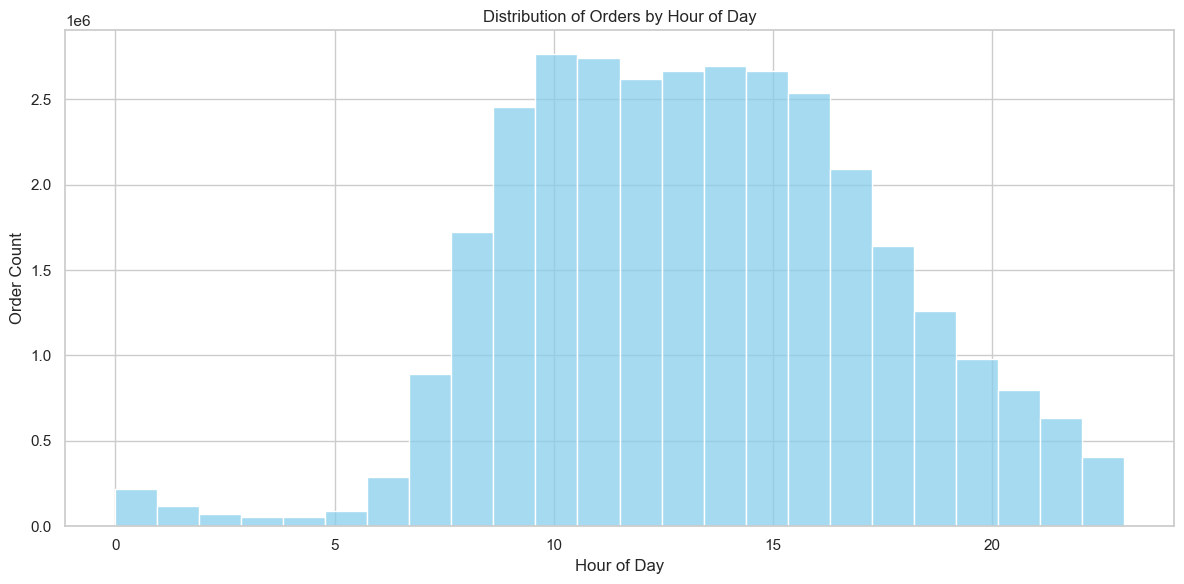

In [20]:
# 3. Histogram of order_hour_of_day

plt.figure(figsize=(12,6))
sns.histplot(df['order_hour_of_day'], bins=24, kde=False, color='skyblue')

plt.title('Distribution of Orders by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Order Count')
plt.tight_layout()

save_path = os.path.join(path, "04 Analysis", "Visualizations", "hist_order_hour_of_day.png")
plt.savefig(save_path)
plt.show()

### Interpretation: Order Hour of Day Histogram

The histogram shows how frequently customers place orders at each hour of the day.  
We can see clear peaks during late morning and early afternoon hours, and lower activity late at night.  
This indicates that customer ordering behavior is not evenly distributed across the day; instead, certain hours consistently receive more orders.

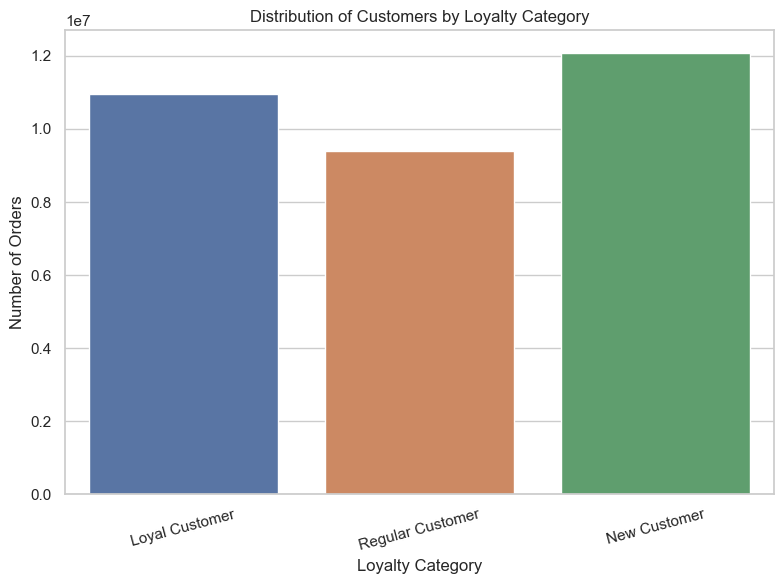

In [21]:
# 4. Bar chart of loyalty_flag

plt.figure(figsize=(8,6))
sns.countplot(data=df, x='loyalty_flag',
              order=['Loyal Customer', 'Regular Customer', 'New Customer'])

plt.title('Distribution of Customers by Loyalty Category')
plt.xlabel('Loyalty Category')
plt.ylabel('Number of Orders')
plt.xticks(rotation=15)
plt.tight_layout()

save_path = os.path.join(path, "04 Analysis", "Visualizations", "bar_loyalty_flag.png")
plt.savefig(save_path)
plt.show()

### Interpretation: Loyalty Flag Bar Chart

This bar chart shows how Instacart orders are distributed across the three loyalty categories:
Loyal Customers, Regular Customers, and New Customers.

The heights of the bars indicate how many orders come from each customer group. This helps the
stakeholders understand which loyalty segments are most active on the platform.

In [8]:
# Create a sample for the line chart (2% of the dataset)
df_sample = df.sample(frac=0.02, random_state=42)

df_sample.head(), df_sample.shape

(          order_id  user_id  order_number  order_dow  order_hour_of_day  \
 21529977    172692   136762             7          2                 18   
 30328970   3397788   192708            21          4                 11   
 28880855   3284232   183456            36          1                 17   
 28950199   1327205   183934             4          4                 11   
 24958750   2299028   158448            22          3                 16   
 
           days_since_prior_order  product_id  add_to_cart_order  reordered  \
 21529977                    25.0       28079                  5          1   
 30328970                    10.0       46473                  7          0   
 28880855                     8.0       21351                  8          1   
 28950199                    24.0        6327                  5          0   
 24958750                     6.0       24852                  7          1   
 
                                                product_name  ... 

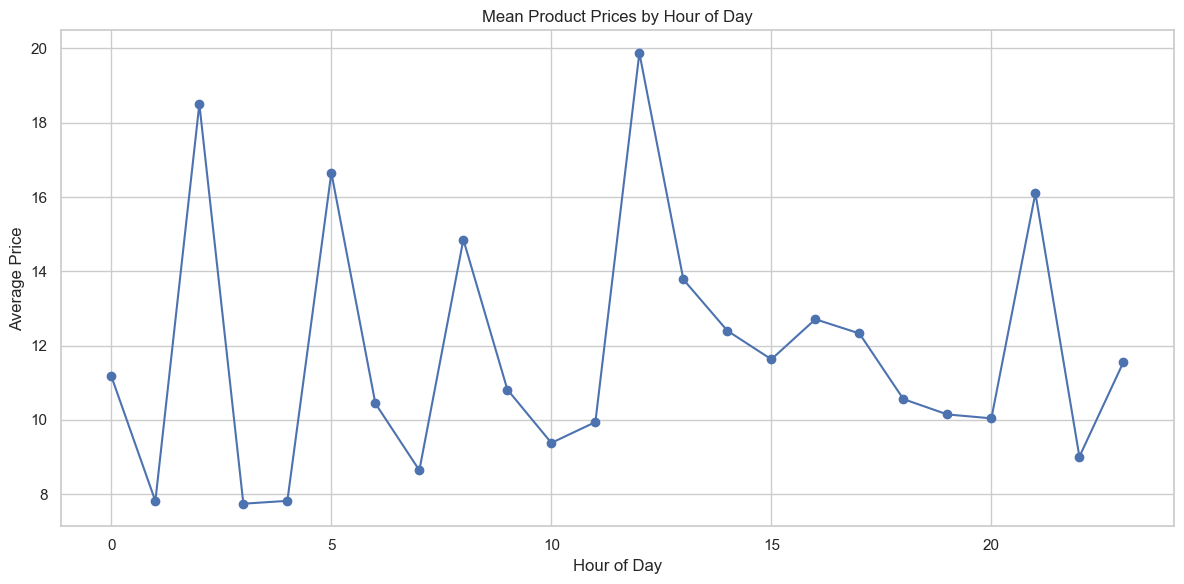

In [22]:
# 5. Line chart: mean price by order hour

line_data = df_sample.groupby('order_hour_of_day')['prices'].mean()

plt.figure(figsize=(12,6))
plt.plot(line_data.index, line_data.values, marker='o')

plt.title('Mean Product Prices by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Price')
plt.grid(True)
plt.tight_layout()

save_path = os.path.join(path, "04 Analysis", "Visualizations", "line_mean_price_by_hour.png")
plt.savefig(save_path)
plt.show()

### Interpretation: Prices by Hour of Day Line Chart

This line chart shows how the average price of purchased products changes depending on the hour of the day.

The values appear relatively stable across hours, with minor fluctuations. This suggests that customers generally buy similarly priced items regardless of the time, and there is no strong spike indicating significantly higher or lower spending at any specific hour.

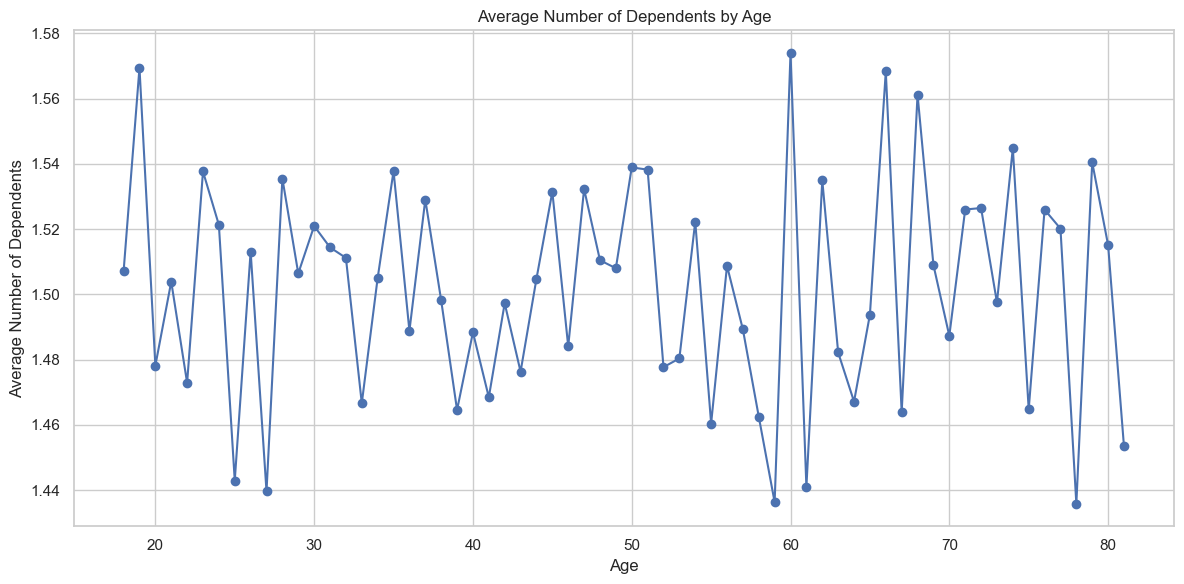

In [23]:
# 6. Line chart: relationship between age and number of dependents

age_dep_data = df.groupby('age')['num_dependents'].mean()

plt.figure(figsize=(12,6))
plt.plot(age_dep_data.index, age_dep_data.values, marker='o')

plt.title('Average Number of Dependents by Age')
plt.xlabel('Age')
plt.ylabel('Average Number of Dependents')
plt.grid(True)
plt.tight_layout()

save_path = os.path.join(path, "04 Analysis", "Visualizations", "line_age_vs_dependents.png")
plt.savefig(save_path)
plt.show()

### Interpretation: Age vs. Number of Dependents

This line chart shows the relationship between customer age and the average number of dependents.

The pattern generally indicates that:
- Younger customers tend to have fewer dependents.
- The number of dependents increases into the late 20s, 30s, and early 40s.
- After middle age, the average number of dependents decreases again, which is expected as children become independent.

Overall, the chart suggests a typical life-stage pattern: customers in their family-raising years tend to have more dependents.

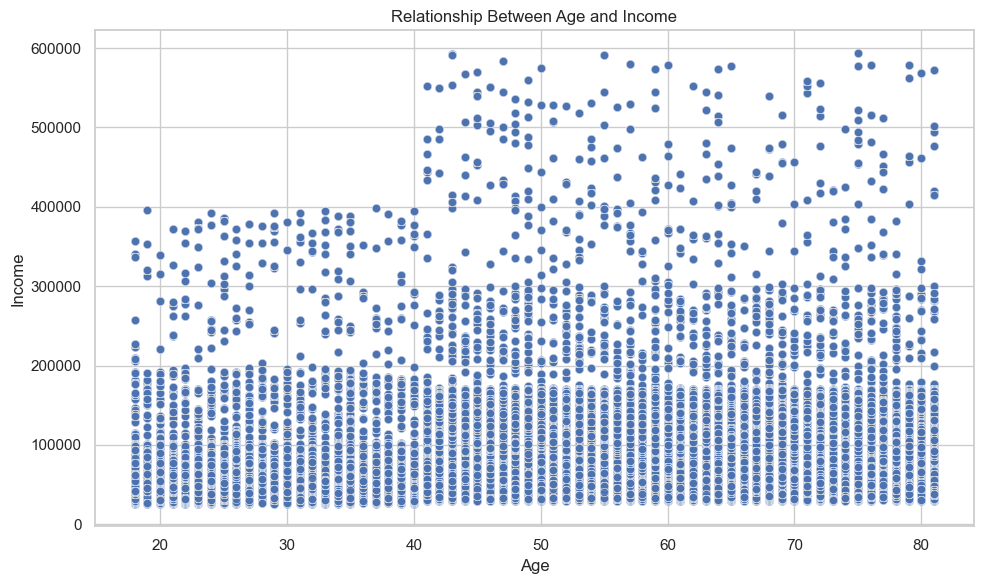

In [24]:
# 7. Scatterplot: relationship between age and income

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='age', y='income', alpha=0.3)

plt.title('Relationship Between Age and Income')
plt.xlabel('Age')
plt.ylabel('Income')
plt.grid(True)
plt.tight_layout()

save_path = os.path.join(path, "04 Analysis", "Visualizations", "scatter_age_income.png")
plt.savefig(save_path)
plt.show()

### Interpretation: Age vs. Income Scatterplot

The scatterplot illustrates the relationship between customer age and income.  
Overall, there is no strong linear correlation, but several patterns can be observed:

- Younger customers tend to have lower incomes with less variation.  
- Income variability increases significantly after age 30.  
- Older customers (50+) show a wider spread of income levels, including many high-income individuals.  
- The distribution suggests that income tends to rise with age but stabilizes and becomes more varied in later adulthood.

These insights can help Instacart tailor marketing strategies to different age-income segments.